In [5]:
!pip install -q diffusers transformers accelerate

Using device: cuda


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Image generate...


  0%|          | 0/25 [00:00<?, ?it/s]

Image successfully save: cyberpunk_city.png


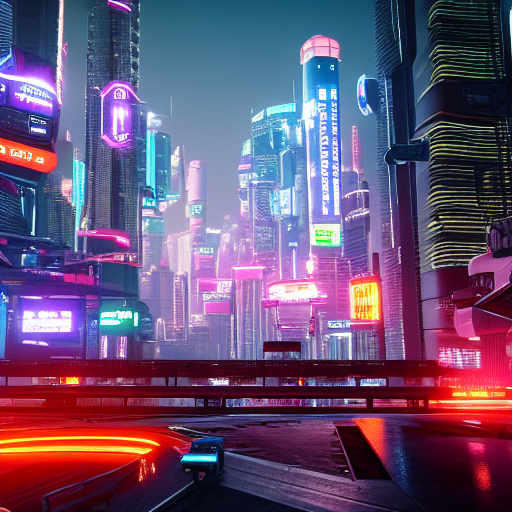

In [ ]:
import os
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from IPython.display import display

# 1. GPU Check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Pipeline Load (float16 for fast GPU inference)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

# Fast scheduler use (DPMSolver++)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

# 3. Parameters define 
prompt = "A futuristic cyberpunk city with neon lights and flying cars, ultra realistic, 8k"
negative_prompt = "blurry, low quality, distorted, bad anatomy"

# Reproducibility mate seed fix 
generator = torch.Generator(device=device).manual_seed(42)

# 4. Image Generate 
print("Image generate...")
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=25,   # Steps (20-30 are optimal)
    guidance_scale=7.5,       # Prompt adherence (CFG)
    generator=generator
).images[0]

# 5. Output save and in notebook display
output_filename = "cyberpunk_city.png"
image.save(output_filename)
print(f"Image successfully save: {output_filename}")

# Image preview in Colab
display(image)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

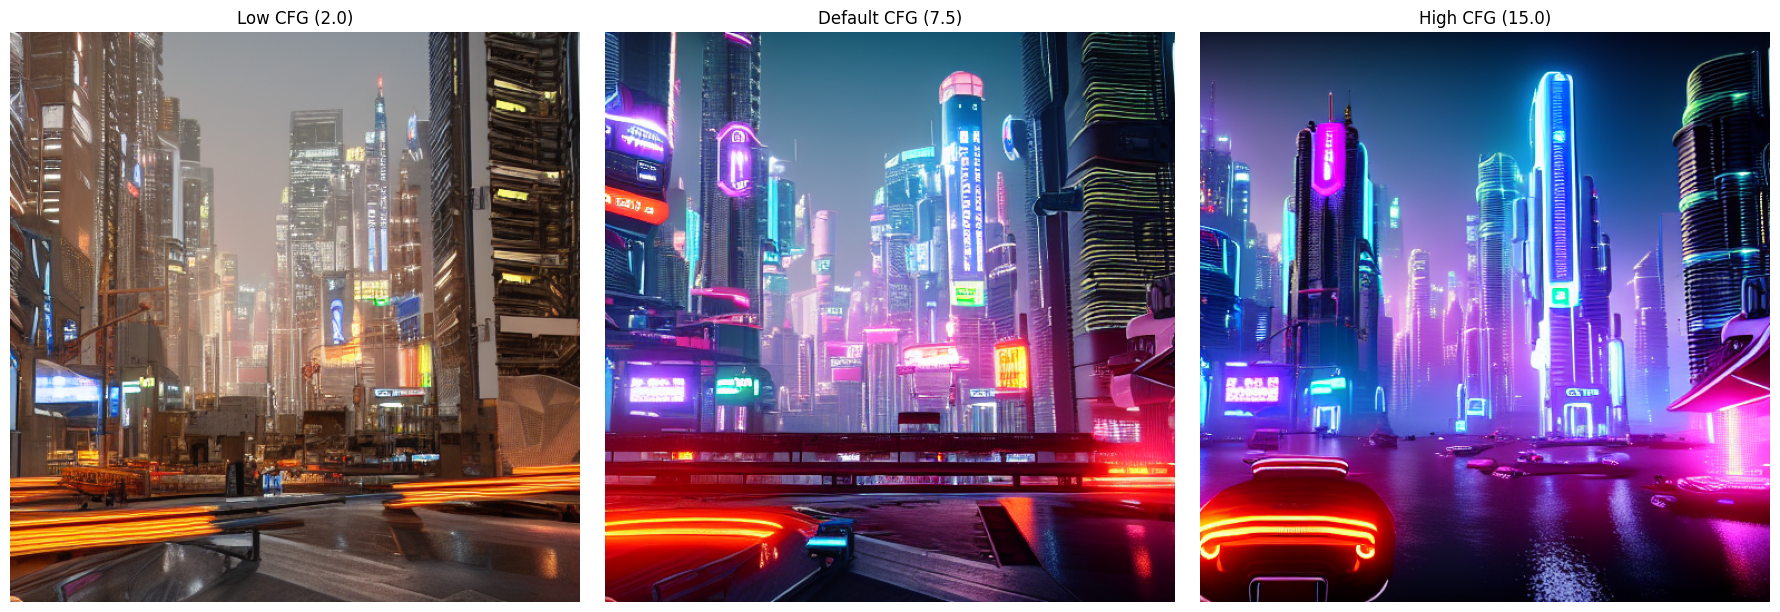

In [7]:
import matplotlib.pyplot as plt

configs = [
    {"name": "Low CFG (2.0)", "steps": 25, "cfg": 2.0},
    {"name": "Default CFG (7.5)", "steps": 25, "cfg": 7.5},
    {"name": "High CFG (15.0)", "steps": 25, "cfg": 15.0},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cfg in enumerate(configs):
    gen = torch.Generator(device=device).manual_seed(42)
    img = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=cfg["steps"],
        guidance_scale=cfg["cfg"],
        generator=gen
    ).images[0]

    axes[i].imshow(img)
    axes[i].set_title(cfg["name"])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Generating image...


  0%|          | 0/28 [00:00<?, ?it/s]

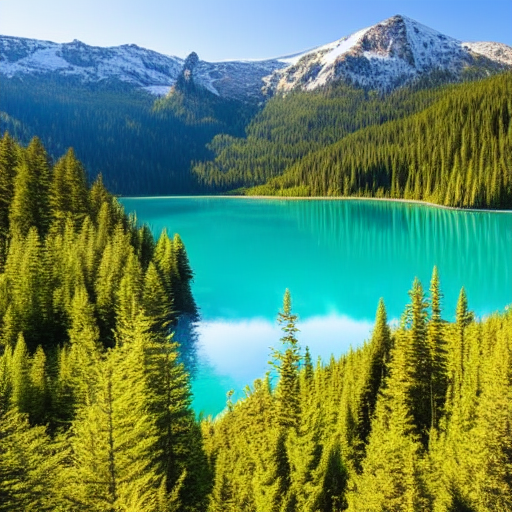

In [9]:
nature_prompt = (
    "A breathtaking cinematic landscape of emerald green alpine meadows, "
    "a crystal-clear reflective mountain lake with turquoise water, "
    "majestic snow-capped mountain peaks in the background, "
    "golden hour sunlight glowing through pine trees, wild flowers blooming, 8k resolution, photorealistic"
)

negative_prompt = "people, buildings, cars, blurry, bad quality, oversaturated, dark, gloomy"

generator = torch.Generator(device=device).manual_seed(2024)

print("Generating image...")
nature_image = pipe(
    prompt=nature_prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=28,
    guidance_scale=7.5,
    generator=generator
).images[0]

nature_image.save("beautiful_nature.png")
display(nature_image)

# Diffusion Models – Practical Work Log

## Objective

Learned the fundamental concepts of Diffusion Models and implemented a text-to-image generation demo using a pre-trained diffusion model.

## Work Completed

* Studied the **Forward Diffusion Process**, where Gaussian noise is gradually added to images.
* Studied the **Reverse Diffusion Process**, where noise is progressively removed to generate an image.
* Understood the role of the **U-Net** in predicting and removing noise during image generation.
* Learned how **text conditioning** guides image generation from text prompts.
* Compared **Diffusion Models vs GANs** and understood their different generation approaches.
* Used Hugging Face **Diffusers** to load a pre-trained text-to-image diffusion pipeline.
* Generated images using multiple **text prompts**.
* Experimented with **inference steps** and **guidance scale** to observe changes in generated outputs.
* Successfully saved generated images as image files.

## Result

Successfully implemented a working **Diffusion Model Image-Generation Demo** that converts text prompts into synthetic images and saves the generated outputs.

## Deliverable

**Diffusion Image-Generation Demo – Completed**

